<h4><b>RNA Regression utilizando biblioteca Pytorch</b></h4>
<p>Experimento com base de dados grande, utilizando toda base e técnica cross_validation</p>

In [3]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [4]:
torch.manual_seed(123)

<h4><b>Carregando dados</b></h4>

In [5]:
path = '/media/marcos/500GB/00_datasets/post_processing/post_processing_dataset.csv'
df = pd.read_csv(path)

In [6]:
df = df[[
    'line_category',
    'line_color',
    'station_initial_latitude',
    'station_initial_longitude',
    'station_final_latitude',
    'station_final_longitude',
    'distance',
    'average_speed_kh',
    'duration'
]]

<h4><b>Atribuindo valores as variáveis X e y</b></h4>

In [7]:
X = df.iloc[:,0:8].values
y = df.iloc[:,8].values

In [8]:
X = torch.tensor(X, dtype=torch.float)
y = torch.tensor(y, dtype=torch.float).view(-1,1)

<h4><b>Divisão em treino e teste</b></h4>

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

<h4><b>Construção do modelo da rede neural</b></h4>
<p>Efetuamos este cálculo visando inicializar a quantidade de neurônios nas camadas ocultas da rede neural.</p>
<p>(entradas + saidas) / 2</p>

<ul>
    <li>Entrada: 8</li>
    <li>Camada oculta: 4 neurônios</li>
    <li>Camada oculta: 4 neurônios</li>
    <li>Camada de saída 1 neurônios</li>
</ul>

In [10]:
regressor = nn.Sequential(
    nn.Linear(8, 4),
    nn.ReLU(),
    nn.Linear(4, 4),
    nn.ReLU(),
    nn.Linear(4, 1)
)

<h4><b>Configurando Hiperparâmetros</b></h4>

In [11]:
epochs = 500
batch_size = 32
learning_rate = 0.001

<h4><b>Configurando loss e optimizer</b></h4>

In [12]:
criterion = nn.L1Loss()
optimizer = optim.Adam(regressor.parameters(), lr=learning_rate)

<h4><b>Inicializando variáveis responsáveis de armazenar histórico das métricas</b></h4>

In [13]:
loss_list = []
mae_list = []
mse_list = []
rmse_list = []
r2_list = []

<h4><b>Preparando o dataset</b></h4>

In [14]:
dataset = TensorDataset(X_train, y_train)

<h4><b>Configurando cross-validation</b></h4>

In [15]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

<h4><b>Treinamento</b></h4>

In [16]:
mae_per_fold = []
mae_test_per_fold = []

mse_per_fold = []
mse_test_per_fold = []

rmse_per_fold = []
rmse_test_per_fold = []

loss_per_fold = []

r2_per_fold = []

# Cross-validation loop
for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
    print(f"Treinando fold {fold + 1}...")
    
    # Dividindo dataset em treino e validação
    train_subsampler = torch.utils.data.Subset(dataset, train_idx)
    val_subsampler = torch.utils.data.Subset(dataset, val_idx)
    
    # DataLoaders e processamento dos batches
    train_loader = DataLoader(train_subsampler, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subsampler, batch_size=batch_size, shuffle=False)
    
    # Inicializando o modelo
    model = regressor
    
    # Loss e optimizer
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    epoch_mae = []
    epoch_mse = []
    epoch_rmse = []
    epoch_losses = []
    epoch_r2 = []
    
    # Loop de treinamento em cada fold
    for epoch in range(epochs):
        running_mae = 0.
        running_mse = 0.
        running_rmse = 0.
        running_loss = 0.
        
        # Treinando cada época
        for i, data in enumerate(train_loader):
            inputs, labels = data
            optimizer.zero_grad()

            # Fazendo as previsões, função forward passa os dados para frente
            # Nesta variável teremos o resultado da última camada
            outputs = model.forward(inputs)
            
            # Calculando loss e metrics
            mae = F.l1_loss(outputs, labels, reduction='sum').item()
            mse = F.mse_loss(outputs, labels, reduction='sum').item()
            rmse = np.sqrt(mse)
            loss = criterion(outputs, labels)
            
            # Inicia processo de backpropagation
            # Volta a estrutura da rede neural, fazendo a atualização dos pesos
            loss.backward()

            # Atualiza os pesos
            optimizer.step()
            
            # Acumulando métricas
            running_mae += mae
            running_mse += mse
            running_rmse += rmse
            running_loss += loss.item()

        # Média das métricas ao longo da época
        mae_res = running_mae / len(train_loader.dataset)
        mse_res = running_mse / len(train_loader.dataset)
        rmse_res = running_rmse / len(train_loader.dataset)
        loss_res = running_loss / len(train_loader.dataset)

        epoch_mae.append(mae_res)
        epoch_mse.append(mse_res)
        epoch_rmse.append(rmse_res)
        epoch_losses.append(loss_res)

        # Calculando R2 score
        val_outputs = model(val_loader.dataset[:][0])
        rss = torch.sum((val_loader.dataset[:][1] - val_outputs) ** 2).item()
        tss = torch.sum((val_loader.dataset[:][1] - val_loader.dataset[:][1].mean()) ** 2).item()
        r2_score = 1 - (rss / tss)

        epoch_r2.append(r2_score)

        # Armazenando os resultados
        mae_list.append(mae_res)
        mse_list.append(mse_res)
        rmse_list.append(rmse_res)
        loss_list.append(loss_res)
        r2_list.append(r2_score)
        
        # Print metricas de cada época
        print(f"Epoch {epoch + 1}/{epochs}, MAE: {mae_res:.4f}, MSE: {mse_res:.4f}, RMSE: {rmse_res:.4f}, Loss: {loss_res:.4f}, R2 Score: {r2_score:.4f}")
            
    mae_per_fold.append(epoch_mae[-1])
    mse_per_fold.append(epoch_mse)
    rmse_per_fold.append(epoch_rmse)
    loss_per_fold.append(epoch_losses)
    r2_per_fold.append(epoch_r2)

    model.eval()  # Coloca em modo de avaliação
    with torch.no_grad():
        val_inputs, val_labels = val_loader.dataset[:]
        val_outputs = model(val_inputs)
        
        mae_test = F.l1_loss(val_outputs, val_labels, reduction='mean').item()
        mse_test = F.mse_loss(val_outputs, val_labels, reduction='mean').item()
        rmse_test = np.sqrt(mse_test)
        
    # Salva o MAE do teste do fold
    mae_test_per_fold.append(mae_test)
    mse_test_per_fold.append(mse_test)
    rmse_test_per_fold.append(rmse_test)
    

# Após cross-validation: Média dos resultados
avg_mae = np.mean(mae_list)
avg_mse = np.mean(mse_list)
avg_rmse = np.mean(rmse_list)
avg_loss = np.mean(loss_list)
avg_r2 = np.mean(r2_list)

print("\nMAE por fold (treino e teste):")
for i, (mae_train, mae_test) in enumerate(zip(mae_per_fold, mae_test_per_fold), 1):
    print(f"Fold {i}: MAE Treino = {mae_train:.4f}, MAE Teste = {mae_test:.4f}")

print('-'*60)

avg_mae_train = np.mean(mae_per_fold)
std_mae_train = np.std(mae_per_fold)
avg_mae_test = np.mean(mae_test_per_fold)
std_mae_test = np.std(mae_test_per_fold)
print(f"MAE Treino: {avg_mae_train:.4f} ± {std_mae_train:.4f}")
print(f"MAE Teste: {avg_mae_test:.4f} ± {std_mae_test:.4f}")

print('-'*60)

avg_mse_train = np.mean(mse_per_fold)
std_mse_train = np.std(mse_per_fold)
avg_mse_test = np.mean(mse_test_per_fold)
std_mse_test = np.std(mse_test_per_fold)
print(f"MSE Treino: {avg_mse_train:.4f} ± {std_mse_train:.4f}")
print(f"MSE Teste: {avg_mse_test:.4f} ± {std_mse_test:.4f}")

print('-'*60)

avg_rmse_train = np.mean(rmse_per_fold)
std_rmse_train = np.std(rmse_per_fold)
avg_rmse_test = np.mean(rmse_test_per_fold)
std_rmse_test = np.std(rmse_test_per_fold)
print(f"RMSE Treino: {avg_rmse_train:.4f} ± {std_rmse_train:.4f}")
print(f"RMSE Teste: {avg_rmse_test:.4f} ± {std_rmse_test:.4f}")

print('-'*60)

print(f"Loss: {avg_loss:.4f}")

print('-'*60)

print(f"R2 Score Treino: {avg_r2:.4f}")

Treinando fold 1...
Epoch 1/500, MAE: 348.3235, MSE: 202826.3048, RMSE: 76.2922, Loss: 10.9015, R2 Score: 0.4868
Epoch 2/500, MAE: 290.3656, MSE: 155747.1296, RMSE: 68.5798, Loss: 9.0952, R2 Score: 0.5126
Epoch 3/500, MAE: 286.1731, MSE: 151803.3343, RMSE: 67.8722, Loss: 8.9636, R2 Score: 0.5071
Epoch 4/500, MAE: 281.1099, MSE: 147885.1476, RMSE: 66.8185, Loss: 8.8223, R2 Score: 0.5425
Epoch 5/500, MAE: 272.7403, MSE: 141120.2376, RMSE: 65.2253, Loss: 8.5468, R2 Score: 0.5615
Epoch 6/500, MAE: 260.1729, MSE: 129273.8080, RMSE: 62.5053, Loss: 8.1472, R2 Score: 0.5626
Epoch 7/500, MAE: 244.1404, MSE: 112688.0367, RMSE: 58.3441, Loss: 7.6358, R2 Score: 0.6805
Epoch 8/500, MAE: 229.5067, MSE: 97940.3042, RMSE: 54.4152, Loss: 7.1888, R2 Score: 0.7205
Epoch 9/500, MAE: 217.7592, MSE: 84340.0479, RMSE: 50.7155, Loss: 6.8166, R2 Score: 0.7485
Epoch 10/500, MAE: 205.3165, MSE: 74023.6400, RMSE: 47.6646, Loss: 6.4310, R2 Score: 0.7729
Epoch 11/500, MAE: 195.1550, MSE: 66366.3318, RMSE: 45.1628, 

In [17]:
model.eval()

with torch.no_grad():
    y_pred_tensor = model(X_test).squeeze()
    y_test_tensor = y_test.squeeze()

In [21]:
mae_test = F.l1_loss(y_pred_tensor, y_test_tensor).item()
mse_test = F.mse_loss(y_pred_tensor, y_test_tensor).item()
rmse_test = np.sqrt(mse_test)
loss_test = criterion(y_pred_tensor, y_test_tensor).item()
rss = torch.sum((y_test_tensor - y_pred_tensor) ** 2).item()
tss = torch.sum((y_test_tensor - y_pred_tensor.mean()) ** 2).item()
r2 = 1 - (rss / tss)

print(f'MAE: {mae_test:.4f}')
print(f'MSE: {mse_test:.4f}')
print(f'RMSE: {rmse_test:.4f}')
print(f'LOSS: {loss_test:.4f}')
print(f'R2: {r2:.4f}')

MAE: 26.5588
MSE: 1390.4751
RMSE: 37.2891
LOSS: 26.5588
R2: 0.9952


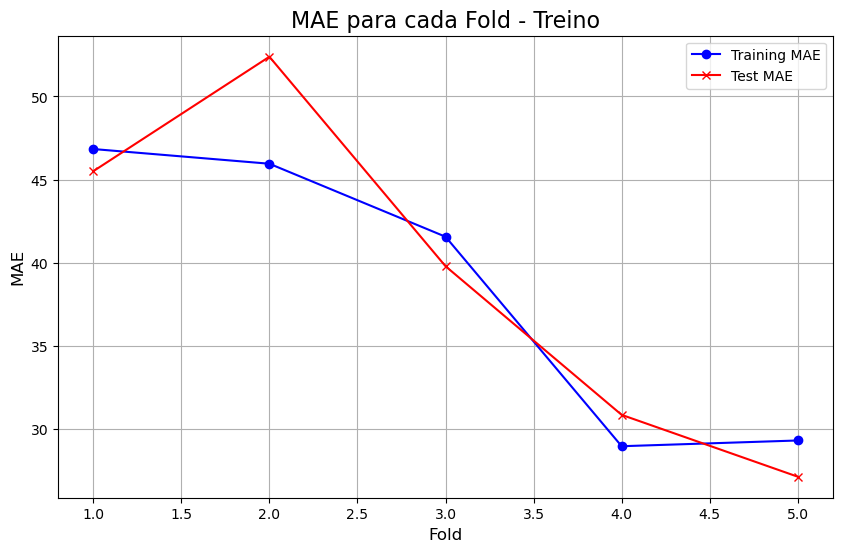

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(range(1, len(mae_per_fold) + 1), mae_per_fold, marker='o', color='blue', label='Training MAE')

plt.plot(range(1, len(mae_test_per_fold) + 1), mae_test_per_fold, marker='x', color='red', label='Test MAE')

plt.title('MAE para cada Fold - Treino', fontsize=16)
plt.xlabel('Fold', fontsize=12)
plt.ylabel('MAE', fontsize=12)

plt.legend()

plt.grid(True)
plt.savefig('rna_mae_per_fold.png')
plt.show()